<a href="https://colab.research.google.com/github/charveeee/PPG-Signal-Processor/blob/main/PPG_Signal_Processor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training the Autoencoder...
Training Complete!

--- STAGE 1: Signal Quality Assessment ---
Calculated Input SNR: 9.15 dB

--- STAGE 2: AI Reconstruction Complete ---

--- STAGE 3: Confidence Score Evaluation ---
AI Reconstruction Confidence: 98.67%

--- STAGE 4: Feature Extraction ---
Detected Systolic Peaks at sample indexes: [  9 113]
Peak-to-Peak Intervals: [104]

--- STAGE 5: Diagnostic Conclusion ---
Conclusion: HEALTHY - Stable sinus rhythm detected.


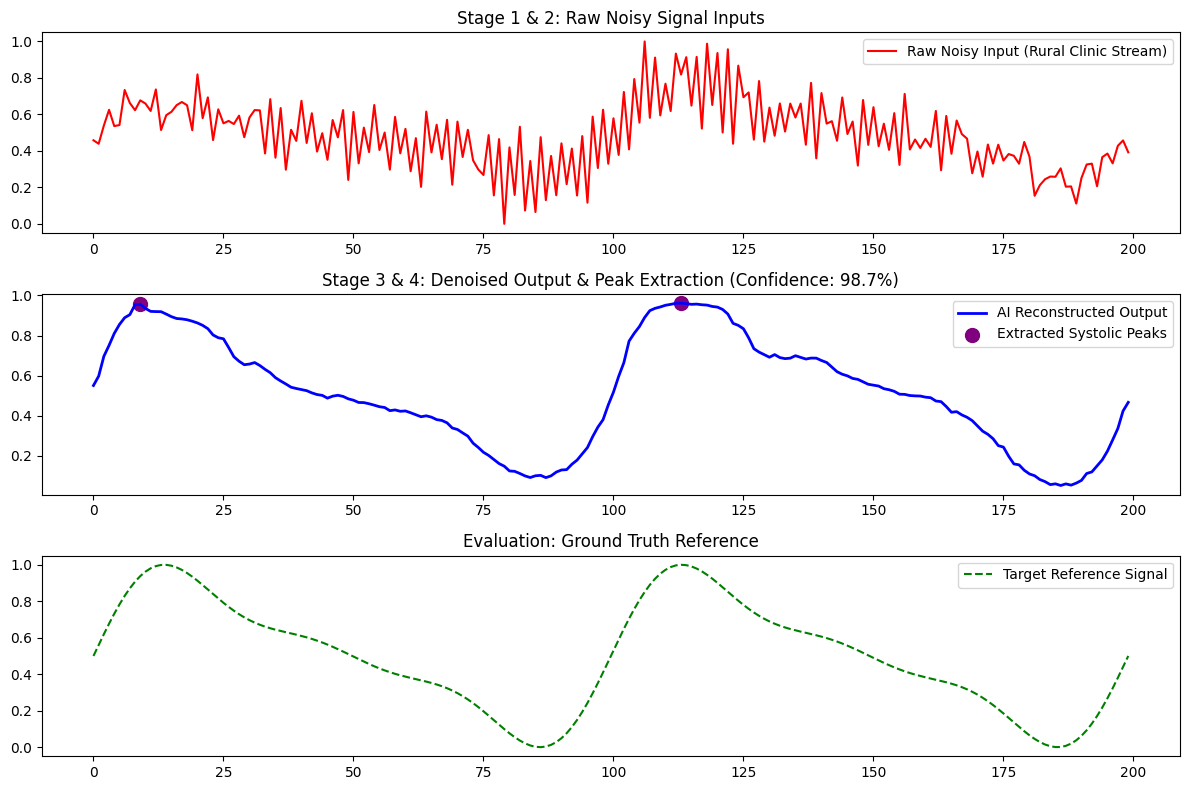

In [ ]:
import numpy as np
import scipy.signal as signal
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


np.random.seed(42)
torch.manual_seed(42)


def generate_synthetic_data(num_samples=500, length=200):
    """Generates pairs of clean PPG waves and noisy equivalents."""
    t = np.linspace(0, 4 * np.pi, length)

    clean_dataset = []
    noisy_dataset = []

    for _ in range(num_samples):

        clean_wave = np.sin(t) + 0.5 * np.sin(2 * t) + 0.2 * np.sin(3 * t)
        clean_wave = (clean_wave - np.min(clean_wave)) / (np.max(clean_wave) - np.min(clean_wave))

        high_freq_noise = 0.3 * np.sin(50 * t)
        baseline_drift = 0.2 * np.sin(0.2 * t)
        random_noise = np.random.normal(0, 0.15, length)

        noisy_wave = clean_wave + high_freq_noise + baseline_drift + random_noise
        noisy_wave = (noisy_wave - np.min(noisy_wave)) / (np.max(noisy_wave) - np.min(noisy_wave))

        clean_dataset.append(clean_wave)
        noisy_dataset.append(noisy_wave)

    return np.array(clean_dataset), np.array(noisy_dataset)


clean_data, noisy_data = generate_synthetic_data()


clean_tensor = torch.FloatTensor(clean_data).unsqueeze(1)
noisy_tensor = torch.FloatTensor(noisy_data).unsqueeze(1)

class SignalDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(SignalDenoisingAutoencoder, self).__init__()


        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU()
        )


        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


model = SignalDenoisingAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)


epochs = 40
batch_size = 32
print("Training the Autoencoder...")
for epoch in range(epochs):
    permutation = torch.randperm(noisy_tensor.size(0))
    for i in range(0, noisy_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_noisy, batch_clean = noisy_tensor[indices], clean_tensor[indices]

        optimizer.zero_grad()
        outputs = model(batch_noisy)
        loss = criterion(outputs, batch_clean)
        loss.backward()
        optimizer.step()

print("Training Complete!\n")


test_index = 0
raw_noisy_signal = noisy_data[test_index]
true_clean_signal = clean_data[test_index]


signal_power = np.mean(true_clean_signal ** 2)
noise_power = np.mean((raw_noisy_signal - true_clean_signal) ** 2)
snr_db = 10 * np.log10(signal_power / noise_power)
print("--- STAGE 1: Signal Quality Assessment ---")
print(f"Calculated Input SNR: {snr_db:.2f} dB")


model.eval()
with torch.no_grad():
    input_sample = torch.FloatTensor(raw_noisy_signal).unsqueeze(0).unsqueeze(0)
    reconstructed_tensor = model(input_sample)
    reconstructed_signal = reconstructed_tensor.squeeze().numpy()
print("\n--- STAGE 2: AI Reconstruction Complete ---")


correlation_matrix = np.corrcoef(reconstructed_signal, true_clean_signal)
confidence_score = correlation_matrix[0, 1] * 100
print("\n--- STAGE 3: Confidence Score Evaluation ---")
print(f"AI Reconstruction Confidence: {confidence_score:.2f}%")


peaks, _ = signal.find_peaks(reconstructed_signal, distance=30, prominence=0.2)
peak_intervals = np.diff(peaks)
interval_variance = np.var(peak_intervals) if len(peak_intervals) > 0 else 0
print("\n--- STAGE 4: Feature Extraction ---")
print(f"Detected Systolic Peaks at sample indexes: {peaks}")
print(f"Peak-to-Peak Intervals: {peak_intervals}")


print("\n--- STAGE 5: Diagnostic Conclusion ---")
if confidence_score < 75.0:
    print("Conclusion: UNRELIABLE DATA. Data corruption too high to safely evaluate.")
elif interval_variance > 2.0:
    print("Conclusion: ALERT - High Heart Rate Variability / Potential Arrhythmia detected.")
else:
    print("Conclusion: HEALTHY - Stable sinus rhythm detected.")


plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(raw_noisy_signal, color='red', label='Raw Noisy Input (Rural Clinic Stream)')
plt.title('Stage 1 & 2: Raw Noisy Signal Inputs')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(reconstructed_signal, color='blue', linewidth=2, label='AI Reconstructed Output')
plt.scatter(peaks, reconstructed_signal[peaks], color='purple', marker='o', s=100, label='Extracted Systolic Peaks')
plt.title(f'Stage 3 & 4: Denoised Output & Peak Extraction (Confidence: {confidence_score:.1f}%)')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(true_clean_signal, color='green', linestyle='--', label='Target Reference Signal')
plt.title('Evaluation: Ground Truth Reference')
plt.legend()

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import scipy.signal as signal
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider

np.random.seed(42)
torch.manual_seed(42)

class SignalDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(SignalDenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def generate_base_dataset(num_samples=500, length=200):
    t = np.linspace(0, 4 * np.pi, length)
    clean_dataset, noisy_dataset = [], []
    for _ in range(num_samples):
        clean_wave = np.sin(t) + 0.5 * np.sin(2 * t) + 0.2 * np.sin(3 * t)
        clean_wave = (clean_wave - np.min(clean_wave)) / (np.max(clean_wave) - np.min(clean_wave))

        noisy_wave = clean_wave + 0.3 * np.sin(50 * t) + 0.2 * np.sin(0.2 * t) + np.random.normal(0, 0.15, length)
        noisy_wave = (noisy_wave - np.min(noisy_wave)) / (np.max(noisy_wave) - np.min(noisy_wave))

        clean_dataset.append(clean_wave)
        noisy_dataset.append(noisy_wave)
    return np.array(clean_dataset), np.array(noisy_dataset)


print("Training base model for interactive dashboard...")
clean_data, noisy_data = generate_base_dataset()
clean_tensor = torch.FloatTensor(clean_data).unsqueeze(1)
noisy_tensor = torch.FloatTensor(noisy_data).unsqueeze(1)

model = SignalDenoisingAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

epochs = 40
batch_size = 32
for epoch in range(epochs):
    permutation = torch.randperm(noisy_tensor.size(0))
    for i in range(0, noisy_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        optimizer.zero_grad()
        outputs = model(noisy_tensor[indices])
        loss = criterion(outputs, clean_tensor[indices])
        loss.backward()
        optimizer.step()
print("Model Ready!\n")



def run_interactive_pipeline(noise_level, hum_freq, drift_level):
    length = 200
    t = np.linspace(0, 4 * np.pi, length)


    true_clean = np.sin(t) + 0.5 * np.sin(2 * t) + 0.2 * np.sin(3 * t)
    true_clean = (true_clean - np.min(true_clean)) / (np.max(true_clean) - np.min(true_clean))


    high_freq_noise = (noise_level) * np.sin(hum_freq * t)
    baseline_drift = (drift_level) * np.sin(0.2 * t)
    random_noise = np.random.normal(0, noise_level * 0.5, length)

    raw_noisy = true_clean + high_freq_noise + baseline_drift + random_noise
    raw_noisy = (raw_noisy - np.min(raw_noisy)) / (np.max(raw_noisy) - np.min(raw_noisy))


    signal_power = np.mean(true_clean ** 2)
    noise_power = np.mean((raw_noisy - true_clean) ** 2)
    snr_db = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else 100


    model.eval()
    with torch.no_grad():
        input_sample = torch.FloatTensor(raw_noisy).unsqueeze(0).unsqueeze(0)
        reconstructed = model(input_sample).squeeze().numpy()


    correlation_matrix = np.corrcoef(reconstructed, true_clean)
    confidence_score = correlation_matrix[0, 1] * 100


    peaks, _ = signal.find_peaks(reconstructed, distance=30, prominence=0.2)
    peak_intervals = np.diff(peaks)
    interval_variance = np.var(peak_intervals) if len(peak_intervals) > 0 else 0


    print(f"📊 SNR: {snr_db:.2f} dB | 🎯 Confidence: {confidence_score:.2f}% | 📍 Peaks Detected: {len(peaks)}")
    if confidence_score < 70.0:
        triage_msg = "Conclusion: ⚠️ UNRELIABLE DATA - Noise too high for diagnostic safety."
    elif interval_variance > 2.0:
        triage_msg = "Conclusion: 🚨 ALERT - Potential Arrhythmia / Irregular Rhythm Detected."
    else:
        triage_msg = "Conclusion: ✅ HEALTHY - Normal Sinus Rhythm."
    print(triage_msg)


    plt.figure(figsize=(12, 7))

    plt.subplot(3, 1, 1)
    plt.plot(raw_noisy, color='crimson', label='Raw Sensor Stream')
    plt.title(f'Raw Input Signal (Grid Hum: {hum_freq}Hz | Drift: {drift_level:.2f})')
    plt.legend(loc='upper right')

    plt.subplot(3, 1, 2)
    plt.plot(reconstructed, color='royalblue', linewidth=2, label='AI Denoised Signal')
    plt.scatter(peaks, reconstructed[peaks], color='darkmagenta', s=90, zorder=5, label='Systolic Peaks')
    plt.title(f'AI Reconstructed Signal (Confidence: {confidence_score:.1f}%)')
    plt.legend(loc='upper right')

    plt.subplot(3, 1, 3)
    plt.plot(true_clean, color='forestgreen', linestyle='--', label='Target Reference Wave')
    plt.title('Ground Truth Baseline')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()



print("--- LIVE PPG SIGNAL DASHBOARD ---")
interact(
    run_interactive_pipeline,
    noise_level=FloatSlider(min=0.0, max=0.8, step=0.05, value=0.3, description='Noise Amp'),
    hum_freq=IntSlider(min=10, max=100, step=10, value=50, description='Grid Hum (Hz)'),
    drift_level=FloatSlider(min=0.0, max=0.5, step=0.05, value=0.2, description='Baseline Drift')
);

Training base model for interactive dashboard...
Model Ready!

--- LIVE PPG SIGNAL DASHBOARD ---


interactive(children=(FloatSlider(value=0.3, description='Noise Amp', max=0.8, step=0.05), IntSlider(value=50,…